<a href="https://colab.research.google.com/github/expeditive/machine-learning/blob/main/project/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [7]:
cars =pd.read_csv('/content/car data.csv')

In [8]:
cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
cars.shape

(301, 9)

In [11]:
cars.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [12]:
#checking missing values
cars.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [13]:
#checking distribution
print(cars.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


In [15]:
print(cars.Seller_Type.value_counts())

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


In [17]:
print(cars.Transmission.value_counts())

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [20]:
#data encoding

cars.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
cars.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
cars.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

<ipython-input-20-b4de2b5e6adf>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


In [21]:
cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [28]:
#data splitting
X = cars.drop(['Car_Name','Present_Price'],axis=1)
Y = cars['Present_Price']

In [29]:
print(X)
print(Y)

     Year  Selling_Price  Kms_Driven  ...  Seller_Type  Transmission  Owner
0    2014           3.35       27000  ...            0             0      0
1    2013           4.75       43000  ...            0             0      0
2    2017           7.25        6900  ...            0             0      0
3    2011           2.85        5200  ...            0             0      0
4    2014           4.60       42450  ...            0             0      0
..    ...            ...         ...  ...          ...           ...    ...
296  2016           9.50       33988  ...            0             0      0
297  2015           4.00       60000  ...            0             0      0
298  2009           3.35       87934  ...            0             0      0
299  2017          11.50        9000  ...            0             0      0
300  2016           5.30        5464  ...            0             0      0

[301 rows x 7 columns]
0       5.59
1       9.54
2       9.85
3       4.15
4       6.87

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state =2)

In [31]:
#loading the model
linear_regression_model = LinearRegression()

In [32]:
linear_regression_model.fit(X_train,Y_train)

LinearRegression()

In [33]:
#model Evaluation
training_data_prediction = linear_regression_model.predict(X_train)

In [34]:
#Rsquared error
error_score = metrics.r2_score(Y_train,training_data_prediction)

In [35]:
print('R square error = ', error_score)

R square error =  0.8477369941761457


Text(0.5, 1.0, 'actual vs predicted')

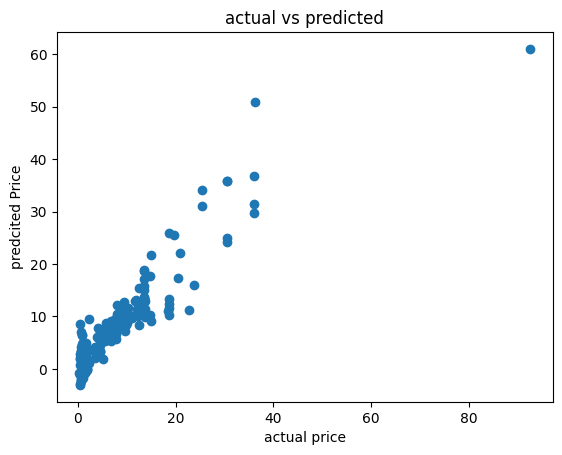

In [36]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel('actual price')
plt.ylabel('predcited Price')
plt.title('actual vs predicted')

In [37]:
test_data_prediction = linear_regression_model.predict(X_test)

In [38]:
error_score = metrics.r2_score(Y_test,test_data_prediction)

In [39]:
print('R squared error=', error_score)

R squared error= 0.8278991998061183


AttributeError: module 'matplotlib.pyplot' has no attribute 'sho'

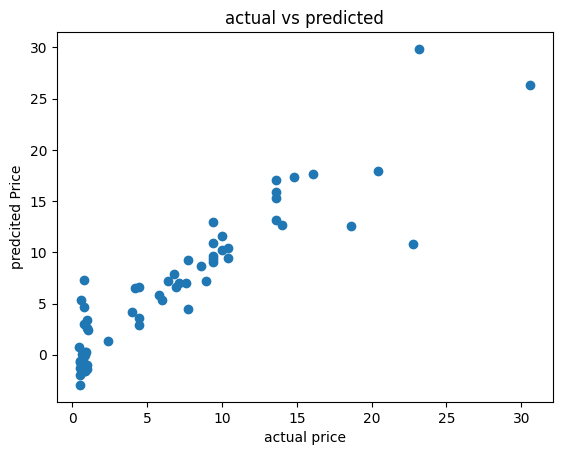

In [40]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel('actual price')
plt.ylabel('predcited Price')
plt.title('actual vs predicted')
plt.sho()